In [2]:
import os
import subprocess

def run(cmd):
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)

In [9]:
url = "https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20181203_biallelic_SNV/ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz"

run(f"wget -c {url}")

wget -c https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20181203_biallelic_SNV/ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz


--2026-04-29 12:15:03--  https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20181203_biallelic_SNV/ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz
Resolving ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)... 193.62.193.167
Connecting to ftp.1000genomes.ebi.ac.uk (ftp.1000genomes.ebi.ac.uk)|193.62.193.167|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [41]:
run("""
plink --vcf ALL.chr1*.vcf.gz \
      --make-bed \
      --out data_chr1
""")


plink --vcf ALL.chr1*.vcf.gz       --make-bed       --out data_chr1

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to data_chr1.log.
Options in effect:
  --make-bed
  --out data_chr1
  --vcf ALL.chr1.shapeit2_integrated_v1a.GRCh38.20181129.phased.vcf.gz

24576 MB RAM detected; reserving 12288 MB for main workspace.
--vcf: data_chr1-temporary.bed + data_chr1-temporary.bim +
data_chr1-temporary.fam written.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to data_chr1.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778798081828384858687

In [44]:
run("""
plink --bfile data_chr1 \
      --maf 0.05 \
      --geno 0.05 \
      --mind 0.05 \
      --make-bed \
      --out data_filtered
""")


plink --bfile data_chr1       --maf 0.05       --geno 0.05       --mind 0.05       --make-bed       --out data_filtered

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to data_filtered.log.
Options in effect:
  --bfile data_chr1
  --geno 0.05
  --maf 0.05
  --make-bed
  --mind 0.05
  --out data_filtered

24576 MB RAM detected; reserving 12288 MB for main workspace.
5795045 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to data_filtered.nosex .
0 people removed due to missing genotype data (--mind).
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737475767778

In [47]:
run("""
plink --bfile data_filtered \
      --set-missing-var-ids @:# \
      --make-bed \
      --out data_fixed
""")

run("""
plink --bfile data_fixed \
      --indep-pairwise 50 5 0.1 \
      --out pruned
""")

run("""
plink --bfile data_fixed \
      --extract pruned.prune.in \
      --make-bed \
      --out data_pruned
""")



plink --bfile data_filtered       --set-missing-var-ids @:#       --make-bed       --out data_fixed

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to data_fixed.log.
Options in effect:
  --bfile data_filtered
  --make-bed
  --out data_fixed
  --set-missing-var-ids @:#

24576 MB RAM detected; reserving 12288 MB for main workspace.
524865 variants loaded from .bim file.
524865 missing IDs set.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to data_fixed.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate i

In [48]:
run("""
plink --bfile data_pruned \
      --pca 10 \
      --out pca_results
""")



plink --bfile data_pruned       --pca 10       --out pca_results

PLINK v1.9.0-b.8 64-bit (22 Oct 2024)              cog-genomics.org/plink/1.9/
(C) 2005-2024 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to pca_results.log.
Options in effect:
  --bfile data_pruned
  --out pca_results
  --pca 10

24576 MB RAM detected; reserving 12288 MB for main workspace.
19803 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to pca_results.nosex .
Using up to 8 threads (change this with --threads).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
19803 variants and 2548 people pass filters and QC.
Note: No phenotypes present.

/var/folders/sx/0f46kbys4kjgkjkxr66v_d7w0000gn/T/ipykernel_93106/2060178344.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pca = pd.read_csv("pca_results.eigenvec", delim_whitespace=True, header=None)


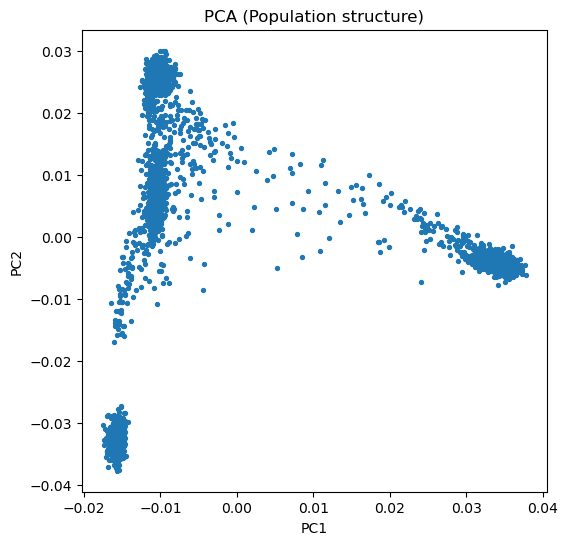

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

pca = pd.read_csv("pca_results.eigenvec", delim_whitespace=True, header=None)

plt.figure(figsize=(6,6))
plt.scatter(pca[2], pca[3], s=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (Population structure)")
plt.show()

In [49]:
run("admixture --cv data_pruned.bed 5 | tee log5.out")


admixture --cv data_pruned.bed 5 | tee log5.out
****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Cross-validation will be performed.  Folds=5.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x19803
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 52.55	Loglikelihood: -5.29865e+07	(delta): 2.37629e

/var/folders/sx/0f46kbys4kjgkjkxr66v_d7w0000gn/T/ipykernel_93106/853018014.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  Q = pd.read_csv("data_pruned.5.Q", delim_whitespace=True, header=None)


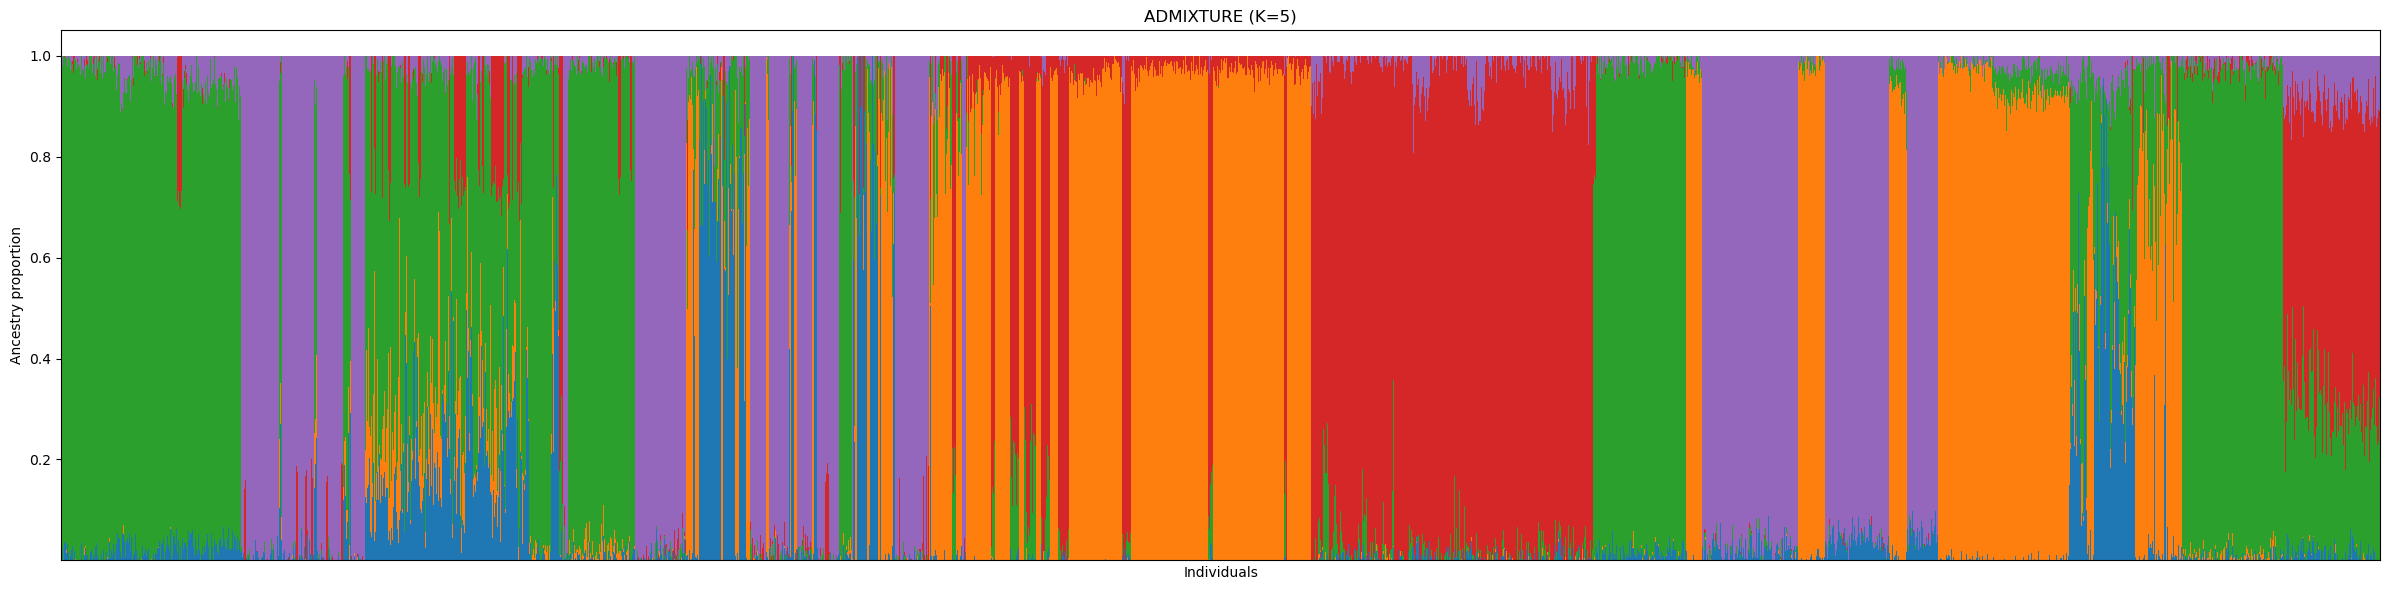

In [54]:
Q = pd.read_csv("data_pruned.5.Q", delim_whitespace=True, header=None)

Q.plot(kind='bar', stacked=True, figsize=(24,6), legend=False, width=1)

plt.xticks([])
plt.xlabel("Individuals")
plt.ylabel("Ancestry proportion")
plt.title("ADMIXTURE (K=5)")

plt.tight_layout()

plt.savefig("admixture_K5.png", dpi=300)  # ← SAVE HERE
plt.show()